# Principal Component Analysis

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

## Loading a dataset

The Iris flower data set consists of 50 samples from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters. Based on the combination of these four features, Fisher developed a linear discriminant model to distinguish each species. Fisher's paper was published in the Annals of Eugenics (today the Annals of Human Genetics).[1]

R. A. Fisher (1936). "The use of multiple measurements in taxonomic problems". Annals of Eugenics. 7 (2): 179–188. doi:10.1111/j.1469-1809.1936.tb02137.x

In [2]:
from sklearn.datasets import load_iris
iris_ = load_iris(as_frame=True)
print(iris_.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [27]:
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df['species'] = iris.target_names[iris.target]
feature_names = iris_df.columns[:4]
iris_df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Univariate EDA

In [4]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
 5   species            150 non-null    object 
dtypes: float64(4), int32(1), object(1)
memory usage: 6.6+ KB


In [5]:
iris_df.describe().round(4)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.0000,150.0000,150.0000,150.0000,150.0000
mean,5.8433,3.0573,3.7580,1.1993,1.0000
std,0.8281,0.4359,1.7653,0.7622,0.8192
min,4.3000,2.0000,1.0000,0.1000,0.0000
25%,5.1000,2.8000,1.6000,0.3000,0.0000
50%,5.8000,3.0000,4.3500,1.3000,1.0000
75%,6.4000,3.3000,5.1000,1.8000,2.0000
max,7.9000,4.4000,6.9000,2.5000,2.0000


In [6]:
X = iris.data
y = iris.target
target_names = iris.target_names

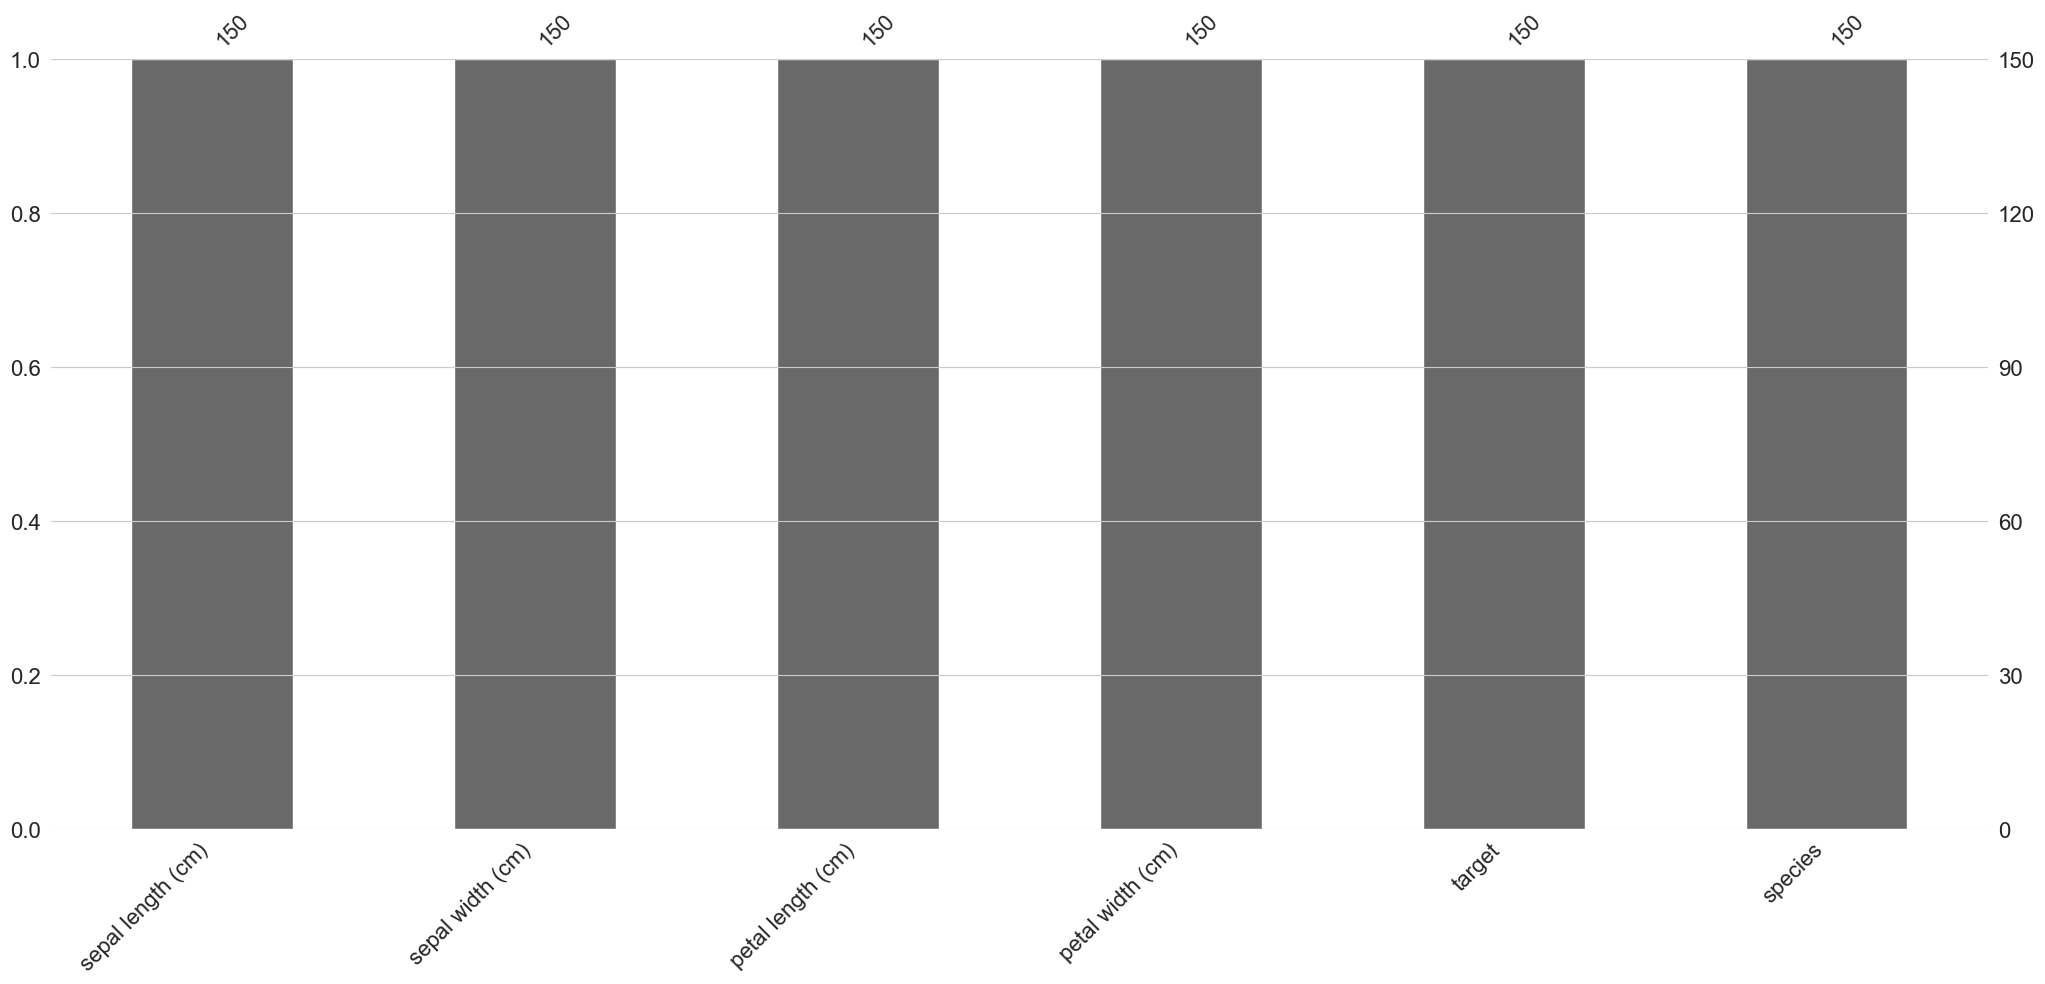

In [7]:
# Null count analysis before modelling to keep check
import missingno as msno
p = msno.bar(iris_df)

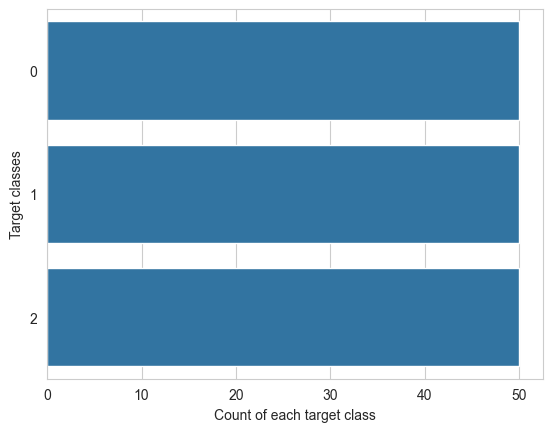

In [8]:
sns.countplot(y=iris.target, data=iris_df)
plt.xlabel('Count of each target class')
plt.ylabel('Target classes')
plt.show()

## Visualizing multivariate data

https://developer.ibm.com/tutorials/awb-implementing-linear-discriminant-analysis-python/

### Boxplots

Bivariate EDA

<Axes: xlabel='species', ylabel='petal width (cm)'>

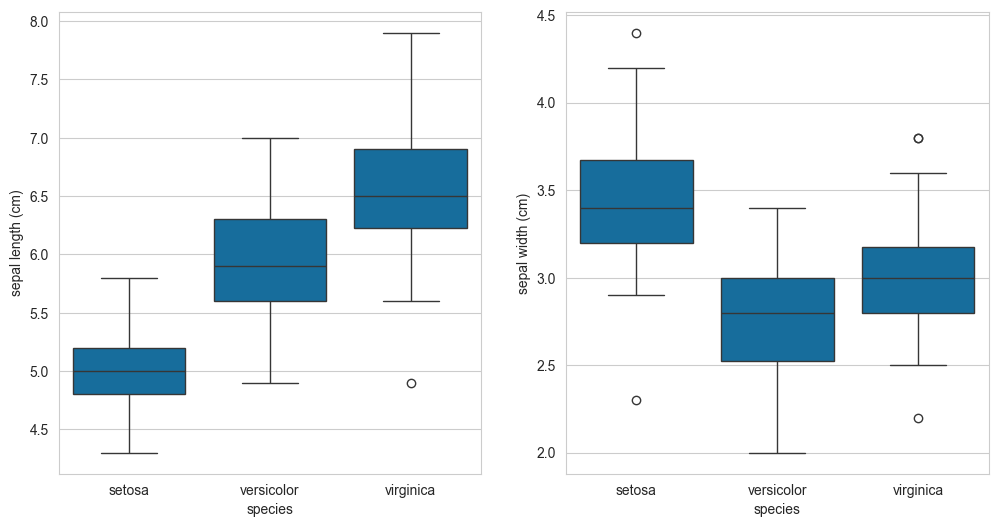

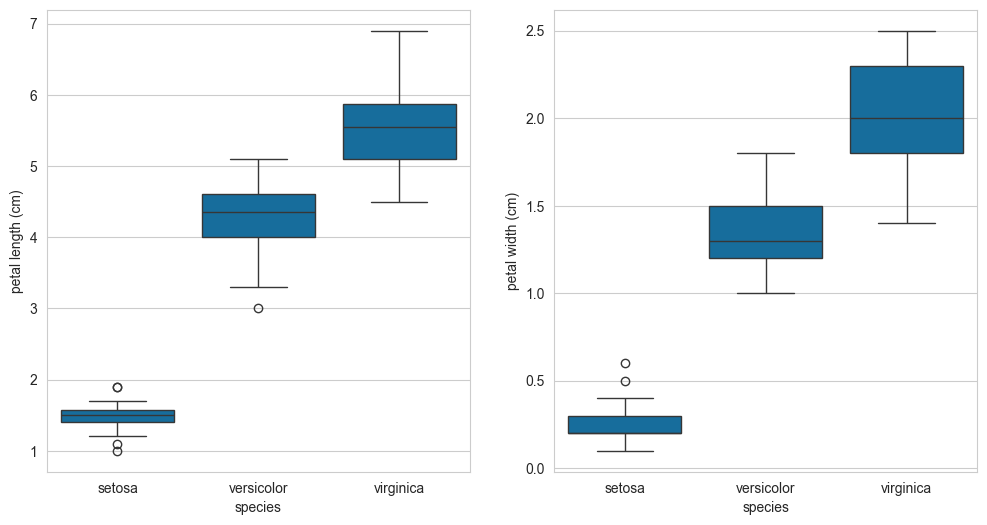

In [44]:
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
sns.boxplot(x='species', y='sepal length (cm)', data=iris_df)
plt.subplot(1, 2, 2)
sns.boxplot(x='species', y='sepal width (cm)', data=iris_df)
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
sns.boxplot(x='species', y='petal length (cm)', data=iris_df)
plt.subplot(1, 2, 2)
sns.boxplot(x='species', y='petal width (cm)', data=iris_df)
#plt.tight_layout()

### Violin Plot

<Axes: xlabel='species', ylabel='petal width (cm)'>

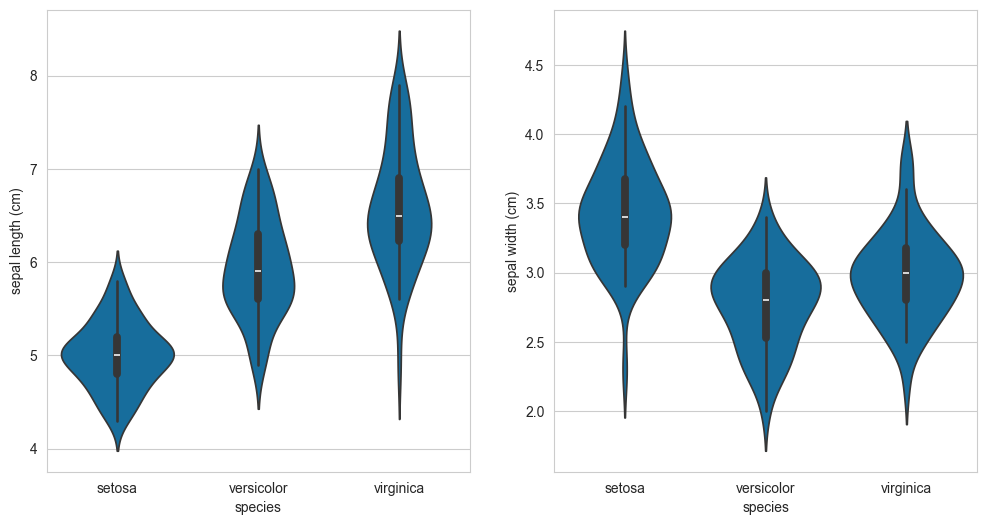

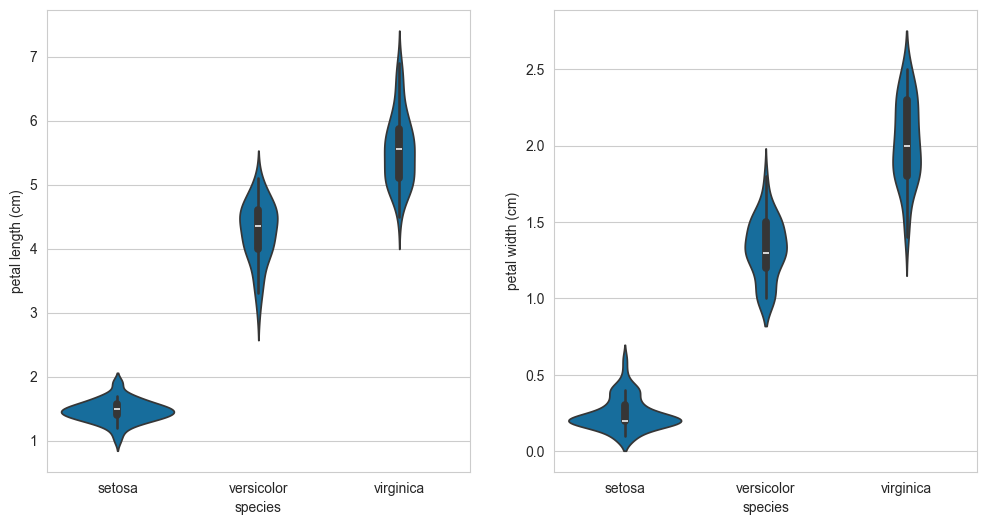

In [45]:
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
sns.violinplot(x='species', y='sepal length (cm)', data=iris_df)
plt.subplot(1, 2, 2)
sns.violinplot(x='species', y='sepal width (cm)', data=iris_df)
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
sns.violinplot(x='species', y='petal length (cm)', data=iris_df)
plt.subplot(1, 2, 2)
sns.violinplot(x='species', y='petal width (cm)', data=iris_df)
#plt.tight_layout()

### Pair plots

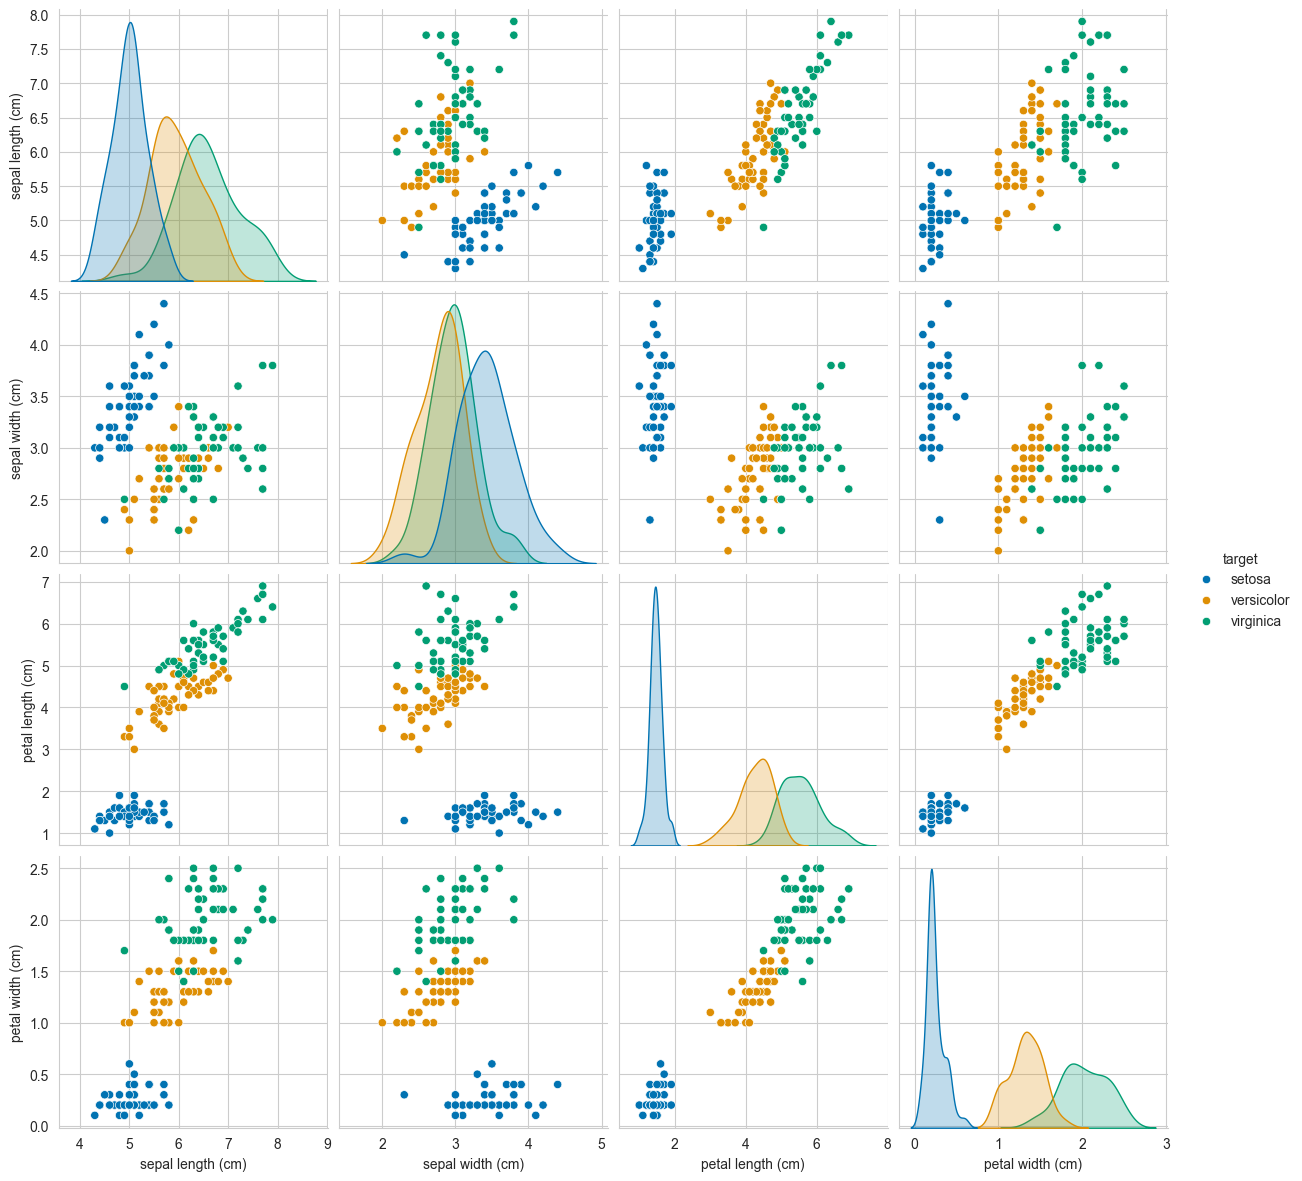

In [46]:
# Visualize the data using scatter plot and histogram
iris_.frame["target"] = iris_.target_names[iris_.target]
sns.set_palette('colorblind')
sns.pairplot(iris_.frame, height=3, hue="target")

The pair plot effectively illustrates how the features vary and correlate across the three classes of coffee samples. In addition, it provides insights into the separability and overlap of these classes within the feature space, facilitating a deeper understanding of the characteristics and differences among the classes. The diagonal plot elements showcase the distribution of each feature, while the off-diagonal plot elements display scatterplots for each pair of features.

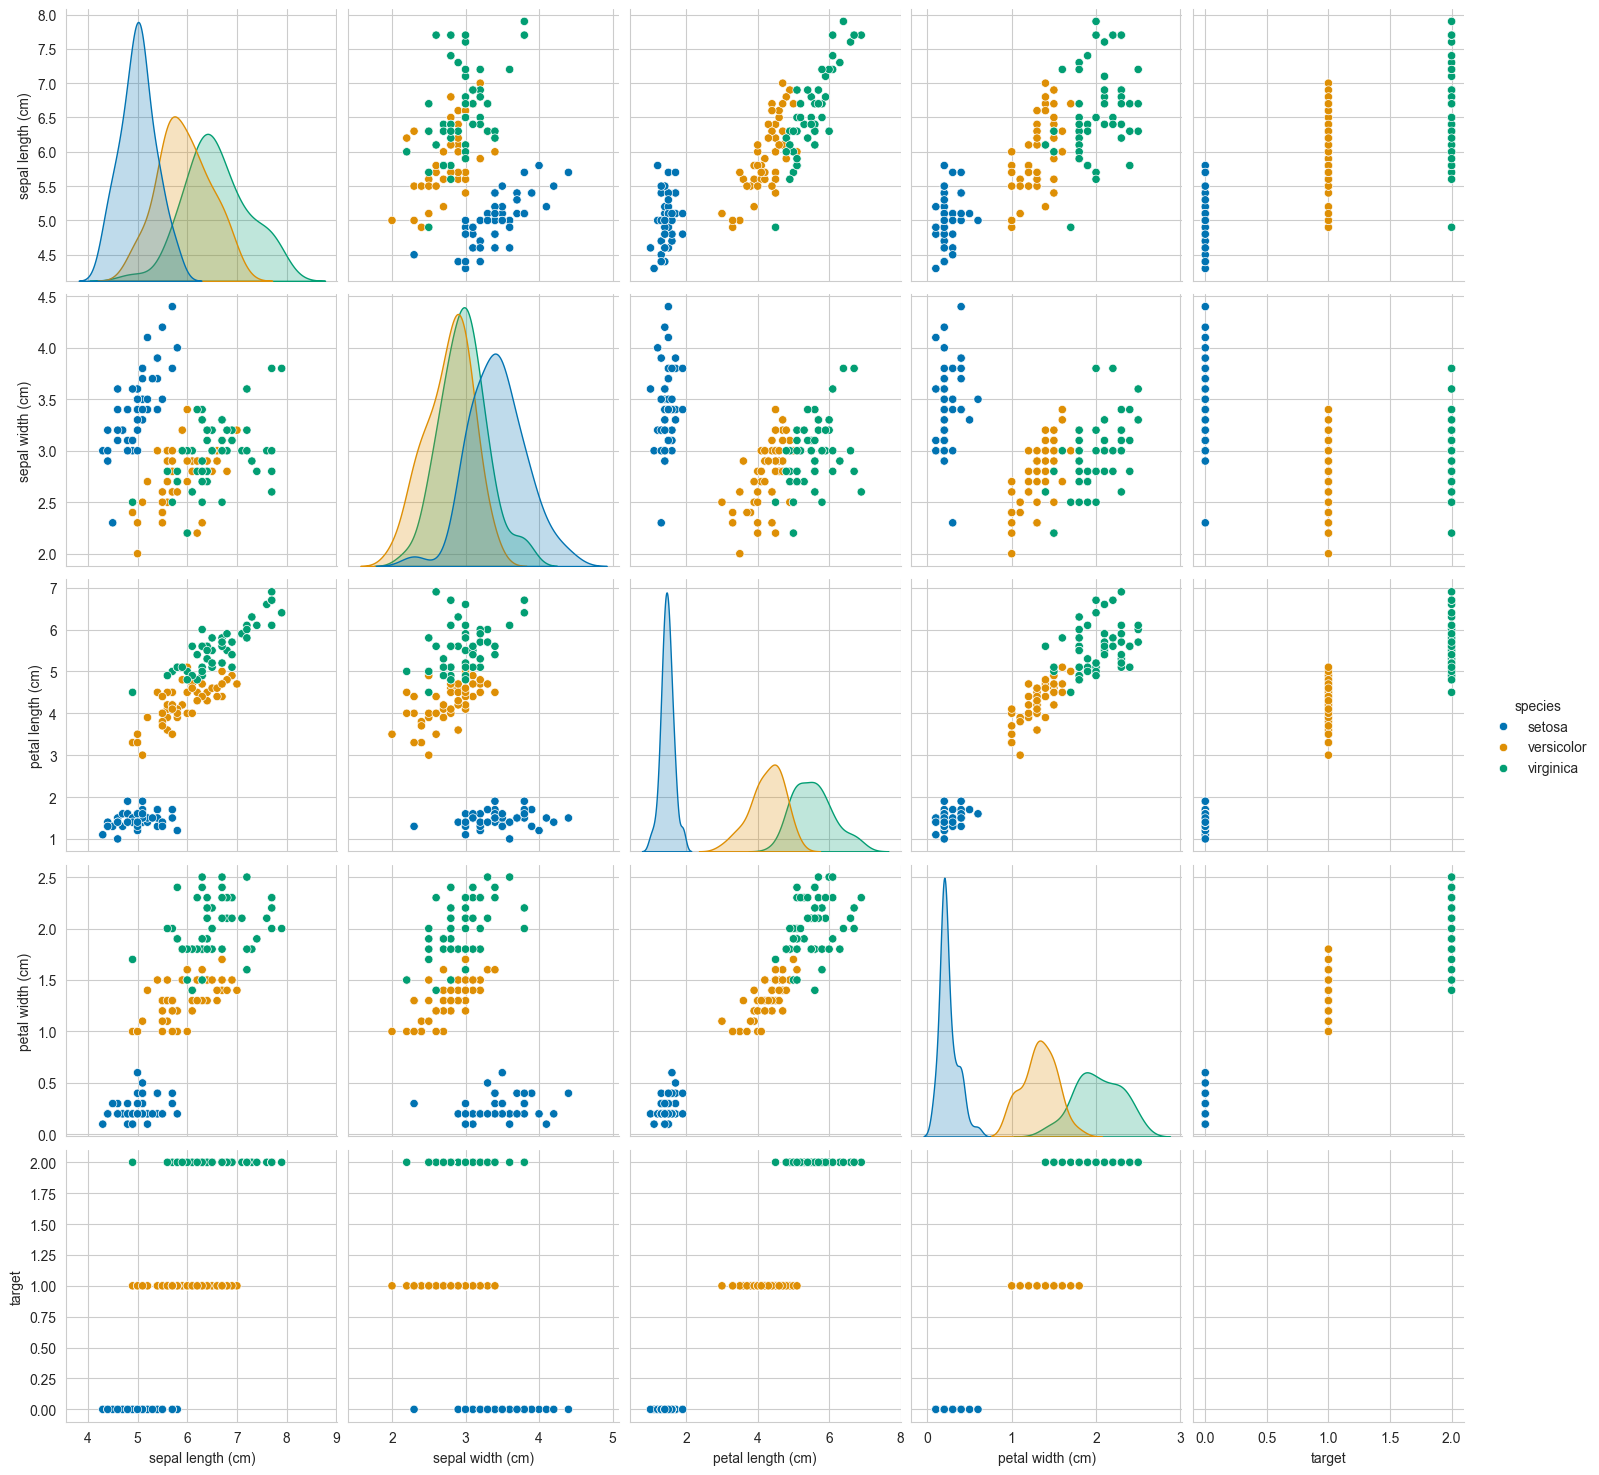

In [47]:
sns.set_palette('colorblind')
sns.pairplot(iris_df, height=3, hue="species")

### Histograms

Histograms are valuable tools for visualizing the distribution of individual features within the coffee dataset.

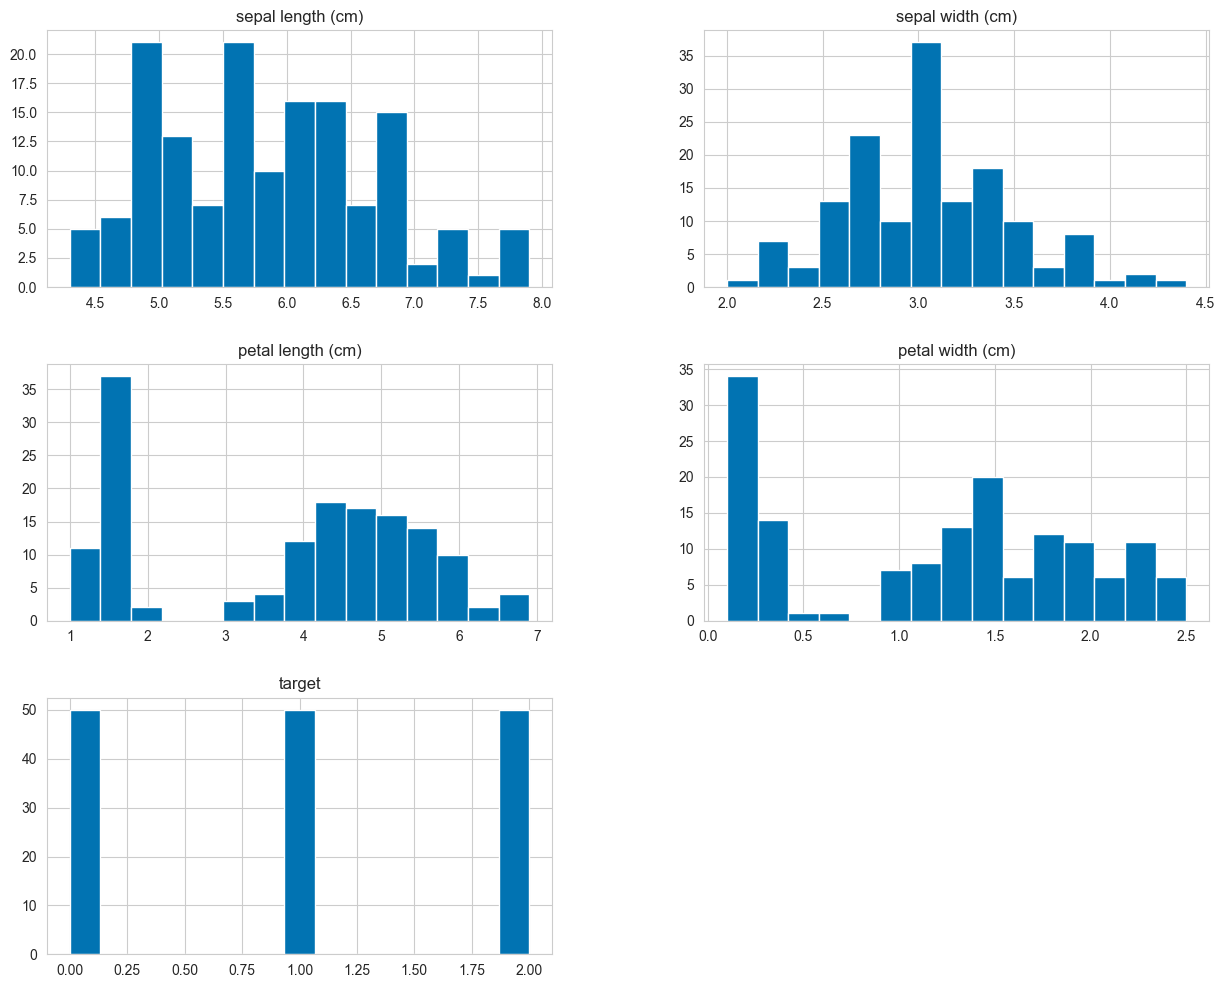

In [48]:
iris_df.hist(figsize=(15,12),bins = 15)
plt.title("Features Distribution")
plt.show()

### Correlation heatmaps

A correlation heatmap offers insights into the relationships between different features in the coffee data set. It plays a critical role in feature selection as it helps identify positive and negative correlations between two variables.

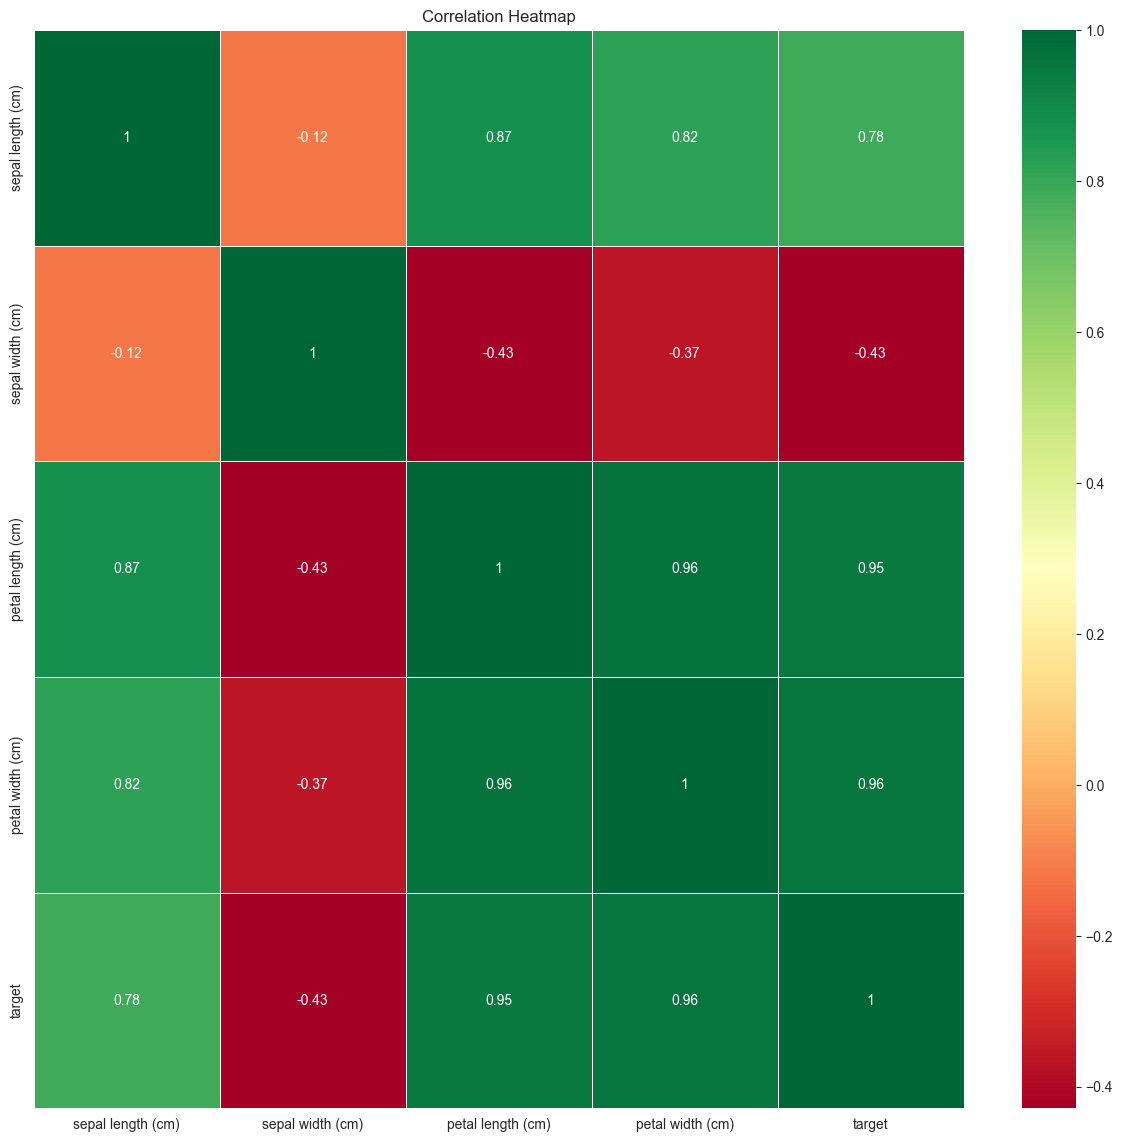

In [49]:
correlation_matrix = iris_df.corr(numeric_only= True)
plt.figure(figsize=(15, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## PCA from scratch

### Step 1 - Data scaling

In [29]:
from sklearn.preprocessing import StandardScaler
"""STEP 1 - Data Scaling"""
x_scaled = StandardScaler().fit_transform(X)

### Step 2 - Find the covariance and correlation matrices

In [31]:
mean_vector = np.mean(x_scaled, axis=0)
covmat = (x_scaled - mean_vector).T.dot((x_scaled - mean_vector))/(x_scaled.shape[0]-1)
# cara lain
covmat_ = np.cov(x_scaled.T)

### Step 3 - Eigen decomposition

In [32]:
"""STEP 3 - Eigen Decomposition"""
# Eigen from covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(covmat_)
# Eigen from correlatioin matrix
cormat = np.corrcoef(x_scaled.T)
eigenvalues_, eigenvectors_ = np.linalg.eig(cormat)

### Step 4 - Sort the eigvals and eigvecs

In [33]:
# Make a list of (eigenvalue, eigenvector) tuples
eigen_pairs = [(np.abs(eigenvalues[i]), eigenvectors[:,i]) for i in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) tuples from high to low
eigen_pairs.sort(key=lambda x_scaled: x_scaled[0], reverse=True)

### Step 5 - Choose PCs by selecting top k eigvecs

In [34]:
# Visually confirm that the list is correctly sorted by decreasing eigenvalues
for a in eigen_pairs:
    if(a[0]>0.1):
        print('Sorted Eignevalues: {}'.format(a[0]))

Sorted Eignevalues: 2.9380850501999927
Sorted Eignevalues: 0.9201649041624892
Sorted Eignevalues: 0.1477418210449476


In [35]:
# For further usage
eig_vals_sorted = np.array([x_scaled[0] for x_scaled in eigen_pairs])
eig_vecs_sorted = np.array([x_scaled[1] for x_scaled in eigen_pairs])

eigval_total = sum(eigenvalues)
explained_variance = [(i/eigval_total) for i in sorted(eigenvalues, reverse=True)]
explained_variance = np.round(explained_variance, 3)

for b in explained_variance:
    if (b>(0.1/100)):
         print('Explained Variance: {}%'.format(round(b*100, 3)))

cum_explained_variance = np.cumsum(explained_variance)
cum_explained_variance = np.round(cum_explained_variance, 3)

for c in cum_explained_variance:
    if (c<0.99):
        print('Cumulative Explained Variance: {}%'.format(round(c*100, 3)))


Explained Variance: 73.0%
Explained Variance: 22.9%
Explained Variance: 3.7%
Explained Variance: 0.5%
Cumulative Explained Variance: 73.0%
Cumulative Explained Variance: 95.9%


### Step 6 - Data projection

In [36]:
"""STEP 6 - Data Projection/Transformation"""
k = 4
W = eig_vecs_sorted[:k, :]

X_proj = x_scaled.dot(W.T)
print(X_proj.shape)

pc_list = ['PC'+ str(i) for i in list(range(1, k+1))]

"""PCA Loading or correlation coefficients"""
loadings = pd.DataFrame.from_dict(dict(zip(pc_list, W)))
print(loadings.head())

"""PCA Scores"""
score = pd.DataFrame.from_dict(dict(zip(pc_list, X_proj)))
df_score = pd.DataFrame(X_proj, columns= pc_list, index=y) # change label
df_score = df_score[df_score.columns[0:k]]

print(df_score.head(5))

(150, 4)
        PC1       PC2       PC3       PC4
0  0.521066 -0.377418 -0.719566  0.261286
1 -0.269347 -0.923296  0.244382 -0.123510
2  0.580413 -0.024492  0.142126 -0.801449
3  0.564857 -0.066942  0.634273  0.523597
        PC1       PC2       PC3       PC4
0 -2.264703 -0.480027 -0.127706  0.024168
0 -2.080961  0.674134 -0.234609  0.103007
0 -2.364229  0.341908  0.044201  0.028377
0 -2.299384  0.597395  0.091290 -0.065956
0 -2.389842 -0.646835  0.015738 -0.035923


### PCA visualization

#### PCA scree plot

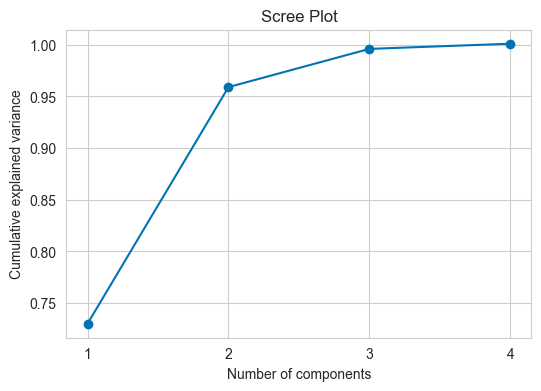

In [37]:
# Scree plot
def scree_plot(cum_expl_var, n_features):
    # change number of features -->
    fig, ax = plt.subplots(figsize=(6,4))
    plt.plot(np.arange(1, n_features+1), cum_expl_var, '-o')
    plt.xticks(np.arange(1, n_features+1))
    plt.xlabel('Number of components')
    plt.ylabel('Cumulative explained variance')
    plt.title('Scree Plot')
    plt.show()

scree_plot(cum_explained_variance, k)

#### PCA score plot

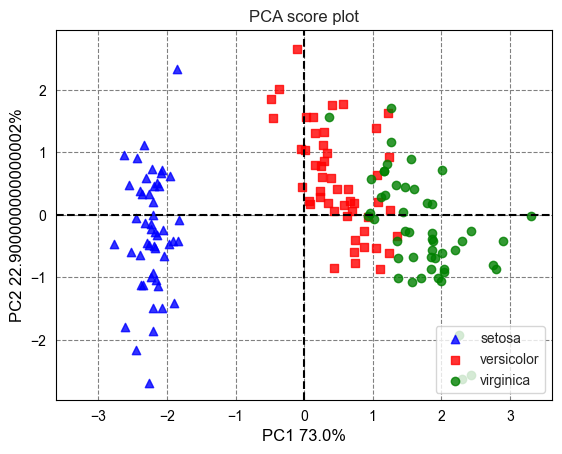

In [39]:
def plot_pca(x_pca, expl_var, target, label_name):
    PC1 = x_pca[:,0]
    PC2 = x_pca[:,1]
    scalePC1 = 1.0/(PC1.max() - PC1.min())
    scalePC2 = 1.0/(PC2.max() - PC2.min())

    ax = plt.subplot(111)
    for label, marker, color in zip(range(0,3), ("^", "s", "o"), ('blue', 'red', 'green')):
        plt.scatter(PC1.real[target==label], PC2.real[target==label],
                    marker=marker, color=color, alpha=0.8, label = target_names)

    plt.legend(label_name, loc = 'lower right')
    plt.title('PCA score plot')
    ax.axhline(y=0.0, color='black', linestyle='dashed', alpha = 1.0) # label = 'Horizontal Line ')
    ax.axvline(x=0.0, color='black', linestyle='dashed', alpha = 1.0) # label = 'Vertical Line ')     # , - -- : None , solid, dashed, dashdot, dotted
    ax.yaxis.grid(color='gray', linestyle='dashed')
    ax.xaxis.grid(color='gray', linestyle='dashed')
    yabs_max = abs(max(ax.get_ylim(), key=abs))
    ax.set_ylim(ymin=-yabs_max, ymax=yabs_max)
    xabs_max = abs(max(ax.get_xlim(), key=abs))
    ax.set_xlim(xmin=-xabs_max, xmax=xabs_max)
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.set_xlabel('PC1 {}%'.format(expl_var[0]*100), size=12).set_color('black')
    ax.set_ylabel('PC2 {}%'.format(expl_var[1]*100), size=12).set_color('black')
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')
    ax.spines['left'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.set_facecolor("white")
    plt.show()

label_name = ['setosa', 'versicolor', 'virginica']
plot_pca(X_proj, explained_variance, y, label_name)


#### PCA biplot

In [40]:
def biplot(W, feature_name):
    fig, ax = plt.subplots(figsize=(6,5))
    for i, feature in enumerate(feature_name):
        ax.arrow(0, 0, W[0,i], W[1,i], head_width = 0.02, head_length = 0.02, color = 'black')
        ax.text(W[0,i]*1.15, W[1,i]*1.15, feature, color = 'black', fontsize=10).set_bbox(dict(facecolor='white', alpha=0.5, edgecolor='gray'))
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)
    ax.set_title('2D PCA Biplot')
    ax.axhline(y=0.0, color='black', linestyle='dashed', alpha = 1.0) # label = 'Horizontal Line ')
    ax.axvline(x=0.0, color='black', linestyle='dashed', alpha = 1.0) # label = 'Vertical Line ')
    ax.yaxis.grid(color='gray', linestyle='dashed')
    ax.xaxis.grid(color='gray', linestyle='dashed')
    yabs_max = abs(max(ax.get_ylim(), key=abs))
    ax.set_ylim(ymin=-(yabs_max+(yabs_max/3)), ymax=(yabs_max+(yabs_max/3)))
    xabs_max = abs(max(ax.get_xlim(), key=abs))
    ax.set_xlim(xmin=-(xabs_max+(xabs_max/3)), xmax=(xabs_max+(xabs_max/3)))
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')
    ax.spines['left'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.set_facecolor("white")
    plt.show()

def pca_coeff(W, feature_name):
    plt.matshow(W[0:2,:], cmap='viridis')
    plt.yticks([0,1], ["First", "Second"], size=14)
    plt.colorbar()
    plt.xticks(range(len(feature_name)),
               feature_name, rotation=60, ha='left', size=12)
    plt.xlabel("Features", size=14)
    plt.ylabel("PCs", size=14)
    plt.show()


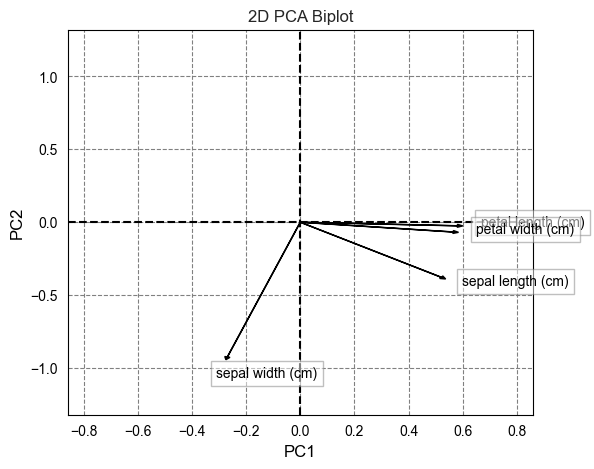

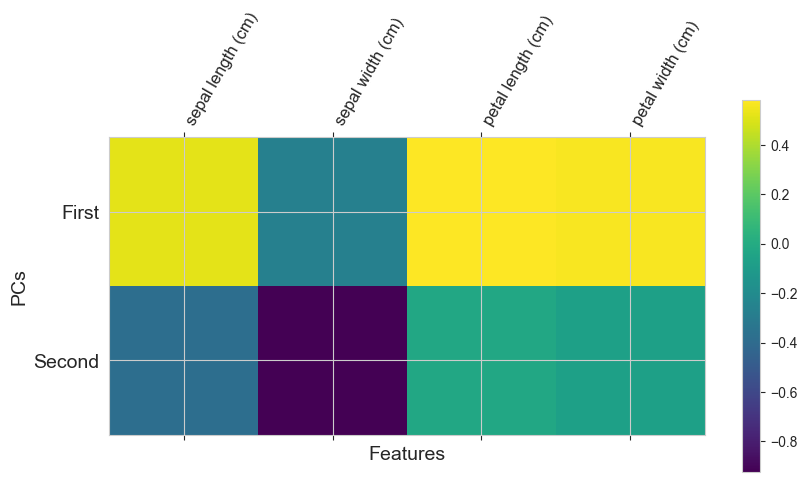

In [41]:
biplot(W, feature_names)
pca_coeff(W, feature_names)

In [21]:
def pca_plot(x_proj, W, explained_variance, n_samples, target, feature_name, label_name):
    PC1 = x_proj[:,0]
    PC2 = x_proj[:,1]
    scalePC1 = 1.0/(PC1.max() - PC1.min())
    scalePC2 = 1.0/(PC2.max() - PC2.min())

    colors = np.random.rand(n_samples)
    fig, ax = plt.subplots(figsize=(7,6))
    ax.scatter(PC1*scalePC1, PC2*scalePC2, c = colors, s=20, label=target)
    plt.colorbar()

    for i, feature in enumerate(feature_name):
        ax.arrow(0, 0, W[0,i], W[1,i], head_width = 0.02, head_length = 0.02, color = 'black')
        ax.text(W[0,i]*1.15, W[1,i]*1.15, feature, color = 'black', fontsize=10).set_bbox(dict(facecolor='gray', alpha=0.5, edgecolor='gray'))
    
    for i, txt in enumerate(target):
        ax.annotate(txt, (PC1[i], PC2[i]), xytext=(5, -5), textcoords='offset points') 

    ax.set_xlabel('PC1 ('+str(round(explained_variance[0]*100,2))+'%)', fontsize=12)
    ax.set_ylabel('PC2 ('+str(round(explained_variance[1]*100,2))+'%)', fontsize=12)
    ax.set_title('2D PCA Biplot')
    ax.axhline(y=0.0, color='black', linestyle='dashed', alpha = 1.0) # label = 'Horizontal Line ')
    ax.axvline(x=0.0, color='black', linestyle='dashed', alpha = 1.0) # label = 'Vertical Line ')
    ax.yaxis.grid(color='gray', linestyle='dashed')
    ax.xaxis.grid(color='gray', linestyle='dashed')
    yabs_max = abs(max(ax.get_ylim(), key=abs))
    ax.set_ylim(ymin=-(yabs_max), ymax=yabs_max)
    xabs_max = abs(max(ax.get_xlim(), key=abs))
    ax.set_xlim(xmin=-(xabs_max), xmax=xabs_max)
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')
    ax.spines['left'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.set_facecolor("white")
    plt.legend(label_name, loc = 'lower left')
    plt.show()

## Refs

In [22]:
# https://learnche.org/pid/latent-variable-modelling/principal-component-analysis/index